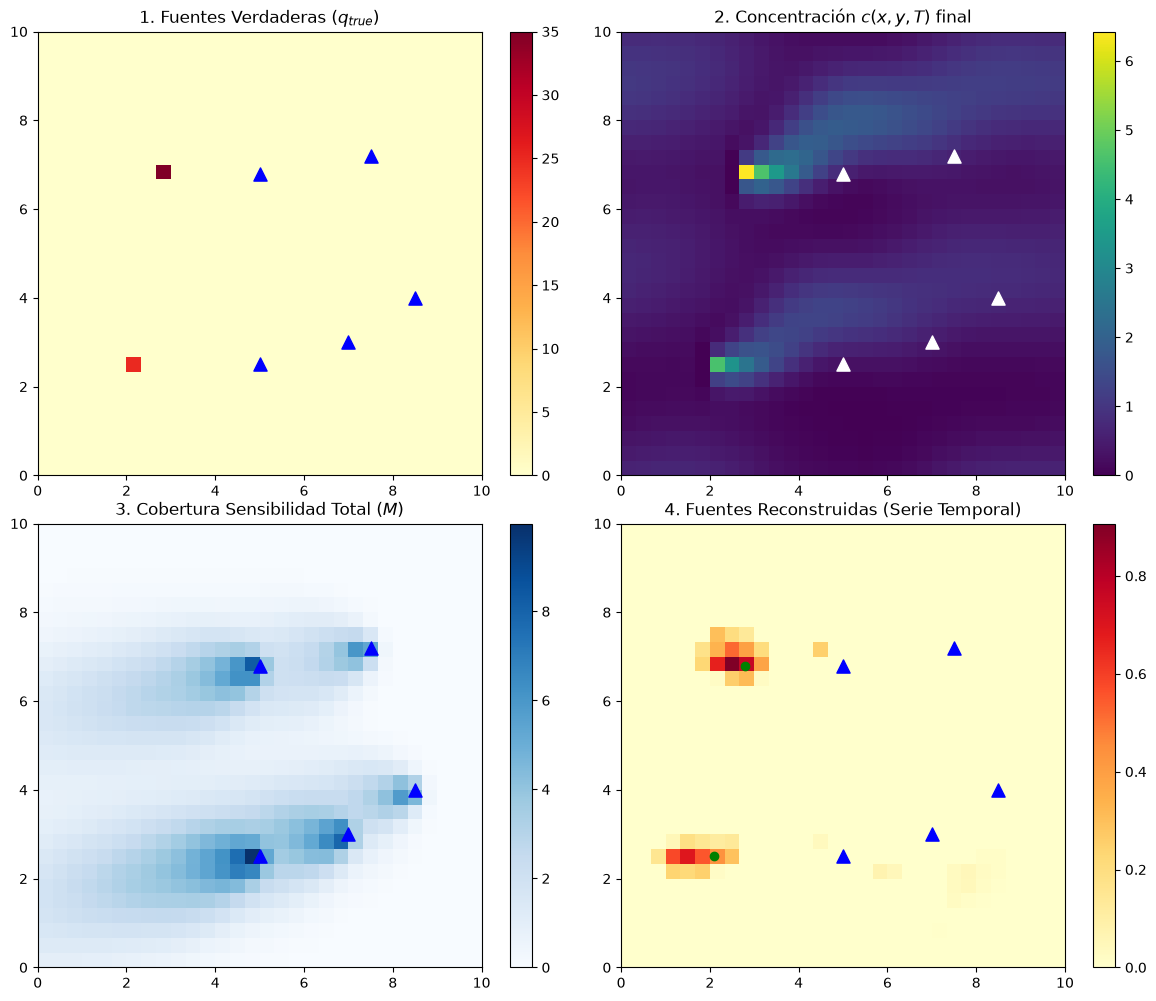

In [73]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import nnls

# -----------------------------------------------------------------------------
# 1. Configuración del Dominio y Viento
# -----------------------------------------------------------------------------
nx, ny = 30, 30
Lx, Ly = 10.0, 10.0
dx, dy = Lx / nx, Ly / ny
X, Y = np.meshgrid(np.linspace(0.5 * dx, Lx - 0.5 * dx, nx), np.linspace(0.5 * dy, Ly - 0.5 * dy, ny))

D = 0.15
dt = 0.05
nt = 140            # T_final = 7.0s
T_final = nt * dt

def dynamic_wind(x_pos, y_pos, t):
    vx = 1.5 + 0.1 * np.sin(2 * np.pi * t / T_final)
    vy = -1.0 * np.cos(2 * np.pi * t * 3/ T_final) + 0.1 * t
    return vx, vy

# -----------------------------------------------------------------------------
# 2. Fuentes Verdaderas y Simulación Directa (Muestreo Multitemporal)
# -----------------------------------------------------------------------------
q_true = np.zeros((ny, nx))
q_true[7, 6] = 25.0    # Fuente A (x ~ 2.1, y ~ 2.5)
q_true[20, 8] = 35.0   # Fuente B (x ~ 2.8, y ~ 6.8)

sensor_coords = np.array([
    [5.0, 2.5], [7.0, 3.0], [5.0, 6.8], [7.5, 7.2], [8.5, 4.0]
])
num_sensors = len(sensor_coords)

# Definimos instantes de tiempo donde los sensores toman muestras
sample_steps = list(range(20, nt, 15))  # Muestras periódicas en t = 1.0s, 1.75s, 2.5s...
num_samples = len(sample_steps)

c = np.zeros((ny, nx))
y_clean_time = []

for step in range(nt):
    t_curr = step * dt
    vx, vy = dynamic_wind(X, Y, t_curr)
    
    dc_dx = (np.roll(c, -1, axis=1) - np.roll(c, 1, axis=1)) / (2 * dx)
    dc_dy = (np.roll(c, -1, axis=0) - np.roll(c, 1, axis=0)) / (2 * dy)
    laplacian = ((np.roll(c, -1, axis=1) - 2 * c + np.roll(c, 1, axis=1)) / (dx**2) +
                 (np.roll(c, -1, axis=0) - 2 * c + np.roll(c, 1, axis=0)) / (dy**2))
    
    dc_dt = -(vx * dc_dx + vy * dc_dy) + D * laplacian + q_true
    c = np.maximum(c + dt * dc_dt, 0)
    
    # Si es un paso de muestreo, registramos las lecturas
    if step in sample_steps:
        y_step = [c[int(sy / dy), int(sx / dx)] for sx, sy in sensor_coords]
        y_clean_time.append(y_step)

y_clean_vec = np.array(y_clean_time).flatten()  # Vector de observaciones (Muestras x Sensores)

# Adición de ruido del 2%
np.random.seed(42)
y_obs_vec = np.maximum(y_clean_vec + np.random.normal(0, 0.02 * np.max(y_clean_vec), size=len(y_clean_vec)), 0)

# -----------------------------------------------------------------------------
# 3. Matriz M Multitemporal (Lagrangiano Inverso por cada instante)
# -----------------------------------------------------------------------------
N_particles = 10000
cell_area = dx * dy
M_rows = []

for s_step in sample_steps:
    for k, (sx, sy) in enumerate(sensor_coords):
        px = np.full(N_particles, sx)
        py = np.full(N_particles, sy)
        residence = np.zeros((ny, nx))
        
        # Inversión temporal desde t_muestra hasta t = 0
        for step in reversed(range(s_step)):
            t_curr = step * dt
            vx, vy = dynamic_wind(px, py, t_curr)
            
            px -= vx * dt - np.sqrt(2 * D * dt) * np.random.normal(0, 1, size=N_particles)
            py -= vy * dt - np.sqrt(2 * D * dt) * np.random.normal(0, 1, size=N_particles)
            
            ix = np.floor(px / dx).astype(int)
            iy = np.floor(py / dy).astype(int)
            valid = (ix >= 0) & (ix < nx) & (iy >= 0) & (iy < ny)
            np.add.at(residence, (iy[valid], ix[valid]), 1)
            
        row = (residence.flatten() * dt) / (N_particles * cell_area)
        M_rows.append(row)

M_time = np.vstack(M_rows)

# -----------------------------------------------------------------------------
# 4. Inversión NNLS sobre Serie Temporal
# -----------------------------------------------------------------------------
lambda_reg = 0.1
M_reg = np.vstack([M_time, lambda_reg * np.eye(nx * ny)])
y_reg = np.concatenate([y_obs_vec, np.zeros(nx * ny)])

q_hat_vec, _ = nnls(M_reg, y_reg)
q_hat = q_hat_vec.reshape((ny, nx))

# -----------------------------------------------------------------------------
# 5. Visualización
# -----------------------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

im0 = axes[0, 0].imshow(q_true, origin='lower', extent=[0, Lx, 0, Ly], cmap='YlOrRd')
axes[0, 0].scatter(sensor_coords[:, 0], sensor_coords[:, 1], color='blue', marker='^', s=90)
axes[0, 0].set_title("1. Fuentes Verdaderas ($q_{true}$)")
fig.colorbar(im0, ax=axes[0, 0])

im1 = axes[0, 1].imshow(c, origin='lower', extent=[0, Lx, 0, Ly], cmap='viridis')
axes[0, 1].scatter(sensor_coords[:, 0], sensor_coords[:, 1], color='white', marker='^', s=90)
axes[0, 1].set_title("2. Concentración $c(x,y,T)$ final")
fig.colorbar(im1, ax=axes[0, 1])

im2 = axes[1, 0].imshow(np.sum(M_time, axis=0).reshape((ny, nx)), origin='lower', extent=[0, Lx, 0, Ly], cmap='Blues')
axes[1, 0].scatter(sensor_coords[:, 0], sensor_coords[:, 1], color='blue', marker='^', s=90)
axes[1, 0].set_title("3. Cobertura Sensibilidad Total ($M$)")
fig.colorbar(im2, ax=axes[1, 0])

im3 = axes[1, 1].imshow(q_hat, origin='lower', extent=[0, Lx, 0, Ly], cmap='YlOrRd')
axes[1, 1].scatter(sensor_coords[:, 0], sensor_coords[:, 1], color='blue', marker='^', s=90)
axes[1, 1].scatter([2.1, 2.8], [2.5, 6.8], color='green')
axes[1, 1].set_title("4. Fuentes Reconstruidas (Serie Temporal)")
fig.colorbar(im3, ax=axes[1, 1])

plt.tight_layout()
plt.show()

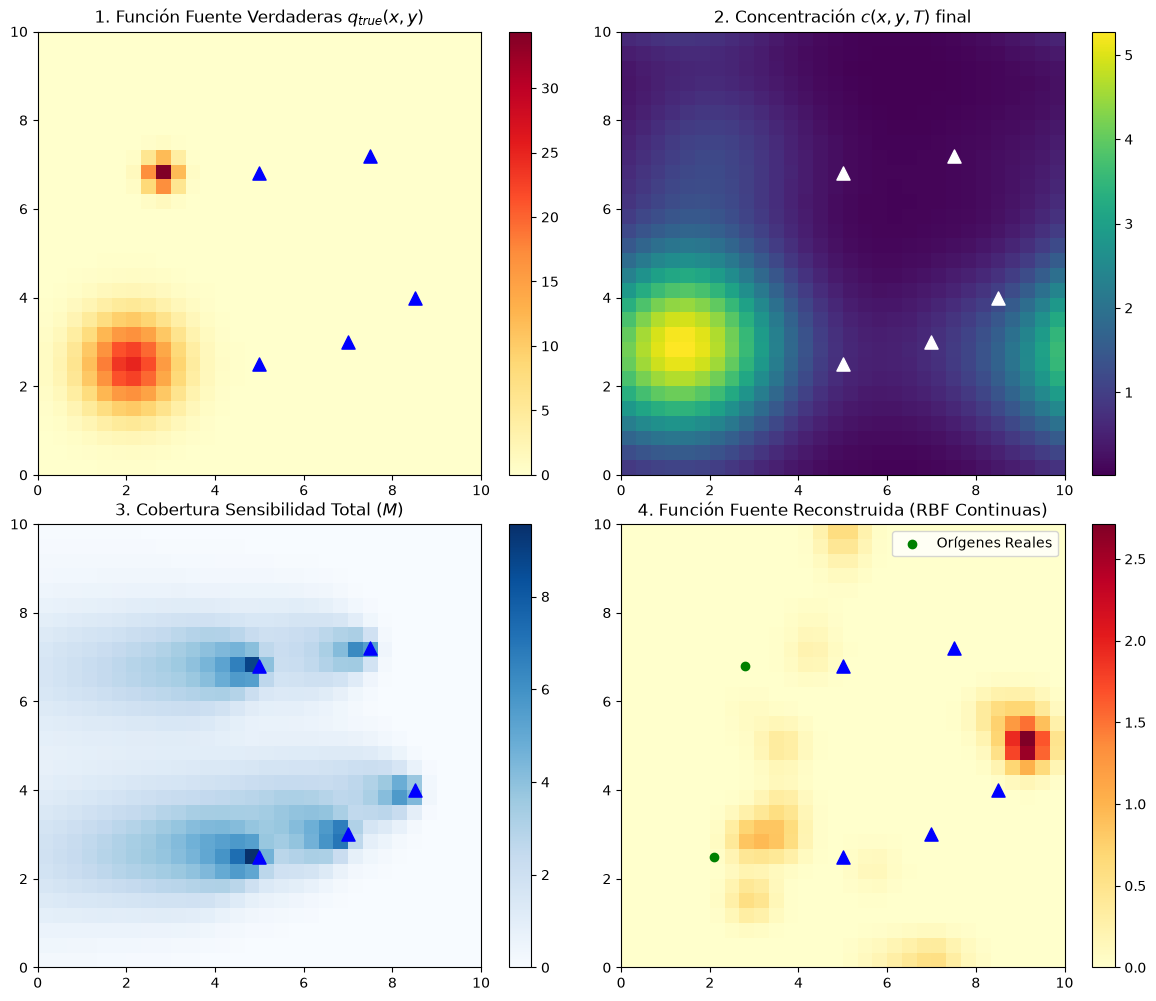

In [77]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import nnls

# -----------------------------------------------------------------------------
# 1. Configuración del Dominio y Viento
# -----------------------------------------------------------------------------
nx, ny = 30, 30
Lx, Ly = 10.0, 10.0
dx, dy = Lx / nx, Ly / ny
X, Y = np.meshgrid(np.linspace(0.5 * dx, Lx - 0.5 * dx, nx), np.linspace(0.5 * dy, Ly - 0.5 * dy, ny))

D = 0.15
dt = 0.05
nt = 140            # T_final = 7.0s
T_final = nt * dt

def dynamic_wind(x_pos, y_pos, t):
    vx = 1.5 + 0.1 * np.sin(2 * np.pi * t / T_final)
    vy = -1.0 * np.cos(2 * np.pi * t * 3 / T_final) + 0.01 * t
    return vx, vy

# -----------------------------------------------------------------------------
# 2. Función Fuente Verdaderas (Continua Espacialmente) y PDE Directa
# -----------------------------------------------------------------------------
def continuous_q_true(x, y):
    # Fuente A centrada en (2.1, 2.5) y Fuente B centrada en (2.8, 6.8)
    source_A = 25.0 * np.exp(-((x - 2.1)**2 + (y - 2.5)**2) / (2 * 0.75**2))
    source_B = 35.0 * np.exp(-((x - 2.8)**2 + (y - 6.8)**2) / (2 * 0.25**2))
    return source_A + source_B

q_true = continuous_q_true(X, Y)

sensor_coords = np.array([
    [5.0, 2.5], [7.0, 3.0], [5.0, 6.8], [7.5, 7.2], [8.5, 4.0]
])
num_sensors = len(sensor_coords)

sample_steps = list(range(20, nt, 15))  # Muestras periódicas
c = np.zeros((ny, nx))
y_clean_time = []

for step in range(nt):
    t_curr = step * dt
    vx, vy = dynamic_wind(X, Y, t_curr)
    
    dc_dx = (np.roll(c, -1, axis=1) - np.roll(c, 1, axis=1)) / (2 * dx)
    dc_dy = (np.roll(c, -1, axis=0) - np.roll(c, 1, axis=0)) / (2 * dy)
    laplacian = ((np.roll(c, -1, axis=1) - 2 * c + np.roll(c, 1, axis=1)) / (dx**2) +
                 (np.roll(c, -1, axis=0) - 2 * c + np.roll(c, 1, axis=0)) / (dy**2))
    
    dc_dt = -(vx * dc_dx + vy * dc_dy) + D * laplacian + q_true
    c = np.maximum(c + dt * dc_dt, 0)
    
    if step in sample_steps:
        y_step = [c[int(sy / dy), int(sx / dx)] for sx, sy in sensor_coords]
        y_clean_time.append(y_step)

y_clean_vec = np.array(y_clean_time).flatten()

# Adición de ruido (2%)
np.random.seed(42)
y_obs_vec = np.maximum(y_clean_vec + np.random.normal(0, 0.02 * np.max(y_clean_vec), size=len(y_clean_vec)), 0)

# -----------------------------------------------------------------------------
# 3. Matriz M Multitemporal (Lagrangiano Inverso)
# -----------------------------------------------------------------------------
N_particles = 10000
cell_area = dx * dy
M_rows = []

for s_step in sample_steps:
    for k, (sx, sy) in enumerate(sensor_coords):
        px = np.full(N_particles, sx)
        py = np.full(N_particles, sy)
        residence = np.zeros((ny, nx))
        
        for step in reversed(range(s_step)):
            t_curr = step * dt
            vx, vy = dynamic_wind(px, py, t_curr)
            
            px -= vx * dt - np.sqrt(2 * D * dt) * np.random.normal(0, 1, size=N_particles)
            py -= vy * dt - np.sqrt(2 * D * dt) * np.random.normal(0, 1, size=N_particles)
            
            ix = np.floor(px / dx).astype(int)
            iy = np.floor(py / dy).astype(int)
            valid = (ix >= 0) & (ix < nx) & (iy >= 0) & (iy < ny)
            np.add.at(residence, (iy[valid], ix[valid]), 1)
            
        row = (residence.flatten() * dt) / (N_particles * cell_area)
        M_rows.append(row)

M_time = np.vstack(M_rows)

# -----------------------------------------------------------------------------
# 4. Construcción de Funciones de Base Radial (RBFs) Espaciales
# -----------------------------------------------------------------------------
n_basis_x, n_basis_y = 15, 15  # Red de 15x15 funciones base continuas
bx = np.linspace(0.5 * dx, Lx - 0.5 * dx, n_basis_x)
by = np.linspace(0.5 * dy, Ly - 0.5 * dy, n_basis_y)
BX, BY = np.meshgrid(bx, by)
centers_x, centers_y = BX.flatten(), BY.flatten()
num_basis = len(centers_x)
sigma_basis = 0.35  # Ancho de dispersión espacial de cada función base

# Matriz de cambio de base B: evalúa cada RBF en cada celda del dominio
X_flat, Y_flat = X.flatten(), Y.flatten()
B = np.zeros((nx * ny, num_basis))
for j in range(num_basis):
    dist_sq = (X_flat - centers_x[j])**2 + (Y_flat - centers_y[j])**2
    B[:, j] = np.exp(-dist_sq / (2 * sigma_basis**2))

# Proyección del operador M a la base de funciones espaciales: M_basis = M * B
M_basis = M_time @ B

# -----------------------------------------------------------------------------
# 5. Inversión NNLS sobre Pesos Espaciales alpha
# -----------------------------------------------------------------------------
lambda_reg = 0.05
M_reg = np.vstack([M_basis, lambda_reg * np.eye(num_basis)])
y_reg = np.concatenate([y_obs_vec, np.zeros(num_basis)])

alpha_hat, _ = nnls(M_reg, y_reg)

# Reconstrucción de la función fuente continua q_hat(x, y) = B * alpha
q_hat_flat = B @ alpha_hat
q_hat = q_hat_flat.reshape((ny, nx))

# -----------------------------------------------------------------------------
# 6. Visualización
# -----------------------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

im0 = axes[0, 0].imshow(q_true, origin='lower', extent=[0, Lx, 0, Ly], cmap='YlOrRd')
axes[0, 0].scatter(sensor_coords[:, 0], sensor_coords[:, 1], color='blue', marker='^', s=90)
axes[0, 0].set_title("1. Función Fuente Verdaderas $q_{true}(x,y)$")
fig.colorbar(im0, ax=axes[0, 0])

im1 = axes[0, 1].imshow(c, origin='lower', extent=[0, Lx, 0, Ly], cmap='viridis')
axes[0, 1].scatter(sensor_coords[:, 0], sensor_coords[:, 1], color='white', marker='^', s=90)
axes[0, 1].set_title("2. Concentración $c(x,y,T)$ final")
fig.colorbar(im1, ax=axes[0, 1])

im2 = axes[1, 0].imshow(np.sum(M_time, axis=0).reshape((ny, nx)), origin='lower', extent=[0, Lx, 0, Ly], cmap='Blues')
axes[1, 0].scatter(sensor_coords[:, 0], sensor_coords[:, 1], color='blue', marker='^', s=90)
axes[1, 0].set_title("3. Cobertura Sensibilidad Total ($M$)")
fig.colorbar(im2, ax=axes[1, 0])

im3 = axes[1, 1].imshow(q_hat, origin='lower', extent=[0, Lx, 0, Ly], cmap='YlOrRd')
axes[1, 1].scatter(sensor_coords[:, 0], sensor_coords[:, 1], color='blue', marker='^', s=90)
axes[1, 1].scatter([2.1, 2.8], [2.5, 6.8], color='green', label='Orígenes Reales')
axes[1, 1].set_title("4. Función Fuente Reconstruida (RBF Continuas)")
axes[1, 1].legend(loc='upper right')
fig.colorbar(im3, ax=axes[1, 1])

plt.tight_layout()
plt.show()